In [ ]:
!mkdir soil_physics_course
!mkdir soil_physics_course/soil_physics_course

In [ ]:
%%writefile soil_physics_course/soil_physics_course/__init__.py
from .swrc import *

Writing soil_physics_course/soil_physics_course/__init__.py


In [ ]:
%%writefile soil_physics_course/soil_physics_course/swrc.py
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erfc


def theta_from_Se(Se, theta_r, theta_s):
    Se = np.clip(Se, 0.0, 1.0)
    return theta_r + (theta_s - theta_r) * Se


def Se_brooks_corey(psi_kpa, psi_b_kpa=10.0, lam=0.6):
    psi_kpa = np.asarray(psi_kpa, dtype=float)
    Se = np.ones_like(psi_kpa)
    mask = psi_kpa > psi_b_kpa
    Se[mask] = (psi_kpa[mask] / psi_b_kpa) ** (-lam)
    return np.clip(Se, 0.0, 1.0)


def Se_van_genuchten(psi_kpa, alpha_kpa_inv=0.05, n=1.6):
    psi_kpa = np.asarray(psi_kpa, dtype=float)
    m = 1.0 - 1.0 / n
    Se = (1.0 + (alpha_kpa_inv * psi_kpa) ** n) ** (-m)
    return np.clip(Se, 0.0, 1.0)


def Se_kosugi(psi_kpa, psi_m_kpa=20.0, sigma=1.0):
    psi_kpa = np.asarray(psi_kpa, dtype=float)
    psi_kpa = np.maximum(psi_kpa, 1e-12)
    z = np.log(psi_kpa / psi_m_kpa) / (np.sqrt(2.0) * sigma)
    Se = 0.5 * erfc(z)
    return np.clip(Se, 0.0, 1.0)


def compute_swrc(
    theta_r=0.05,
    theta_s=0.45,
    psi_b=10.0,
    lam=0.60,
    alpha=0.05,
    n_vg=1.60,
    psi_m=20.0,
    sigma_k=1.00,
):
    psi = np.logspace(-2, 4, 800)

    Se_BC = Se_brooks_corey(psi, psi_b_kpa=psi_b, lam=lam)
    Se_VG = Se_van_genuchten(psi, alpha_kpa_inv=alpha, n=n_vg)
    Se_K = Se_kosugi(psi, psi_m_kpa=psi_m, sigma=sigma_k)

    theta_BC = theta_from_Se(Se_BC, theta_r, theta_s)
    theta_VG = theta_from_Se(Se_VG, theta_r, theta_s)
    theta_K = theta_from_Se(Se_K, theta_r, theta_s)

    return psi, theta_BC, theta_VG, theta_K


def plot_swrc_comparison(
    theta_r=0.05,
    theta_s=0.45,
    psi_b=10.0,
    lam=0.60,
    alpha=0.05,
    n_vg=1.60,
    psi_m=20.0,
    sigma_k=1.00,
):
    psi, theta_BC, theta_VG, theta_K = compute_swrc(
        theta_r, theta_s, psi_b, lam, alpha, n_vg, psi_m, sigma_k
    )

    fig, ax = plt.subplots(figsize=(12.0, 4.2))

    ax.plot(psi, theta_BC, lw=2, label="Brooks–Corey")
    ax.plot(psi, theta_VG, lw=2, label="van Genuchten")
    ax.plot(psi, theta_K, lw=2, label="Kosugi")

    ax.set_xscale("log")
    ax.set_xlabel("Suction |ψ| (kPa)")
    ax.set_ylabel("Volumetric water content, θ (–)")
    ax.set_ylim(0, theta_s * 1.05)
    ax.grid(True, which="both", ls=":", alpha=0.5)
    ax.legend(frameon=False)
    ax.set_title("Same soil: model comparison")

    plt.tight_layout()
    plt.show()

Writing soil_physics_course/soil_physics_course/swrc.py


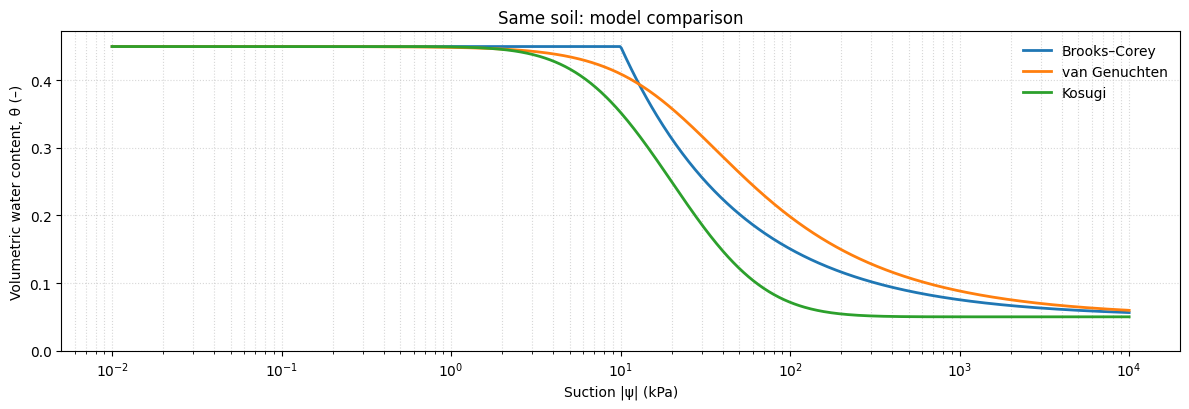

In [ ]:
import sys
sys.path.append("soil_physics_course")

from soil_physics_course import *

plot_swrc_comparison()